In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/cleaned_data.csv
/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/urban_grid_hour.csv
/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/acn_station_hour.csv


# Observation

## Key Findings – Phase 1

1. ACN demand is highly zero-inflated due to station-hour expansion.

2. UrbanEV demand shows substantial variation across grid regions.

3. Log-transformed demand appears approximately normal for UrbanEV and may improve forecasting performance.

4. Revenue distributions closely mirror demand distributions, indicating demand is the primary driver of revenue.

5. UrbanEV provides richer demand dynamics than ACN and will likely become the primary dataset for demand forecasting and tariff optimization.

## phase 2
### Observation 1: Hourly Demand Pattern

- Demand peaks overnight and early morning, with highest charging around 06:00.
- Midmorning demand declines sharply, then gradually recovers through evening hours.

### Observation 2: Weekday vs Weekend Demand

- Weekend demand slightly exceeds weekdays, though overall charging patterns remain similar.
- Demand consistency suggests limited influence from weekday versus weekend travel.

### Observation 3: Demand Heatmap Analysis

- Heatmap shows strongest demand overnight and early mornings across all days.
- Similar daily patterns indicate routines drive charging more than weekdays.

## phase 3

### Observation 4: Utilization Distribution

- Most charging sessions show low utilization, indicating substantial network spare capacity.
- High-utilization observations are uncommon, concentrated within relatively few charging locations.

### Observation 5: Utilization and Congestion Patterns

- Utilization peaks during early mornings, aligning closely with highest demand.
- Severe congestion remains rare, suggesting adequate capacity across most locations.

### Observation 6: High-Utilization Locations

- Few grids consistently exhibit elevated utilization, indicating potential congestion hotspots.
- These locations are ideal candidates for localized pricing and capacity interventions.

## phase 4
### Observation 7: CBD vs Non-CBD Charging Behavior

- Non-CBD areas exhibit higher demand and utilization than CBD charging locations.
- Charging activity appears concentrated in residential and mixed-use non-CBD regions.

### Observation 8: Underutilized Grids

- Several grids consistently show very low utilization, indicating excess capacity.
- These locations present opportunities for incentives to attract additional demand.

### Observation 9: Demand vs Capacity Relationship

- Charger capacity alone does not strongly explain variations in charging demand.
- Location-specific factors appear more influential than infrastructure size alone.

### Observation 10: Utilization vs Capacity Relationship

- Utilization remains relatively consistent across sites with varying charger capacities.
- Demand generally scales with capacity, limiting congestion at larger locations.

## phase 5
### Observation 12: Price–Demand Relationship

- Higher charging prices generally correspond with lower demand across the network.
- Results indicate a moderate negative relationship between price and demand.

### Observation 13: Price–Utilization Relationship

- Higher charging tariffs are associated with lower charger utilization levels.
- Utilization demonstrates a moderate negative relationship with charging price levels.

### Observation 14: Revenue vs Utilization

- Revenue generally increases as charger utilization rises across charging locations.
- Highly utilized sites generate greater revenue despite occasional local variations.

### Observation 15: Demand Elasticity Proxy

- Average demand declines steadily as charging prices increase across groups.
- Users demonstrate measurable sensitivity to price changes in charging services.

## phase 6

### Observation 16: Demand Autocorrelation

- Demand shows strong temporal dependence across consecutive hourly charging observations.
- Daily and weekly patterns remain highly consistent across observed periods.

### Observation 17: Peak-Hour Identification

- Peak charging demand occurs during midnight and early morning hours.
- Hours 00:00, 01:00, 05:00, 06:00, and 07:00 dominate demand.

### Observation 18: Utilization Threshold Discovery

- Most charging observations remain below fifty percent utilization across locations.
- Utilization above sixty percent represents relatively uncommon high-demand operating conditions.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

In [3]:
acn_final=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/acn_station_hour.csv',parse_dates=["hour"])
urban_hourly=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/urban_grid_hour.csv',parse_dates=["hour"])
cleaned_data=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/cleaned_data.csv',parse_dates=["hour"])

/tmp/ipykernel_16/1865063460.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  cleaned_data=pd.read_csv('/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/cleaned_data.csv',parse_dates=["hour"])


# EDA 1-> Data Quality & Dataset Overview

In [4]:
summary = pd.DataFrame({
    "Dataset": [
        "ACN",
        "UrbanEV",
        "Unified"
    ],

    "Rows": [
        len(acn_final),
        len(urban_hourly),
        len(cleaned_data)
    ],

    "Columns": [
        acn_final.shape[1],
        urban_hourly.shape[1],
        cleaned_data.shape[1]
    ],

    "Start_Date": [
        acn_final["hour"].min(),
        urban_hourly["hour"].min(),
        cleaned_data["hour"].min()
    ],

    "End_Date": [
        acn_final["hour"].max(),
        urban_hourly["hour"].max(),
        cleaned_data["hour"].max()
    ]
})

summary

,Dataset,Rows,Columns,Start_Date,End_Date
0,ACN,304182,16,2018-04-25 11:00:00,2018-12-16 03:00:00
1,UrbanEV,177840,23,2022-06-19 00:00:00,2022-07-18 23:00:00
2,Unified,482022,11,2018-04-25 11:00:00,2022-07-18 23:00:00


In [5]:
print(
    "ACN Stations:",
    acn_final["entity_id"].nunique()
)
print(
    "UrbanEV Grids:",
    urban_hourly["entity_id"].nunique()
)
print(
    "Unified Entities:",
    cleaned_data["entity_id"].nunique()
)

ACN Stations: 54
UrbanEV Grids: 247
Unified Entities: 302


In [6]:

acn_final.isna().sum().sort_values(
    ascending=False
).head(20)


entity_id              0
hour                   0
demand_kwh             0
num_sessions           0
avg_session_kwh        0
avg_connected_hours    0
avg_charging_hours     0
price                  0
revenue                0
hour_of_day            0
day_of_week            0
is_weekend             0
month                  0
region                 0
data_source            0
entity_type            0
dtype: int64

In [7]:
urban_hourly.isna().sum().sort_values(
    ascending=False
).head(20)

entity_id             0
hour                  0
demand_kwh            0
avg_occupancy         0
avg_duration_hours    0
price                 0
charger_count         0
fast_count            0
slow_count            0
area                  0
lon                   0
la                    0
CBD                   0
dynamic_pricing       0
revenue               0
utilization_rate      0
hour_of_day           0
day_of_week           0
is_weekend            0
month                 0
dtype: int64

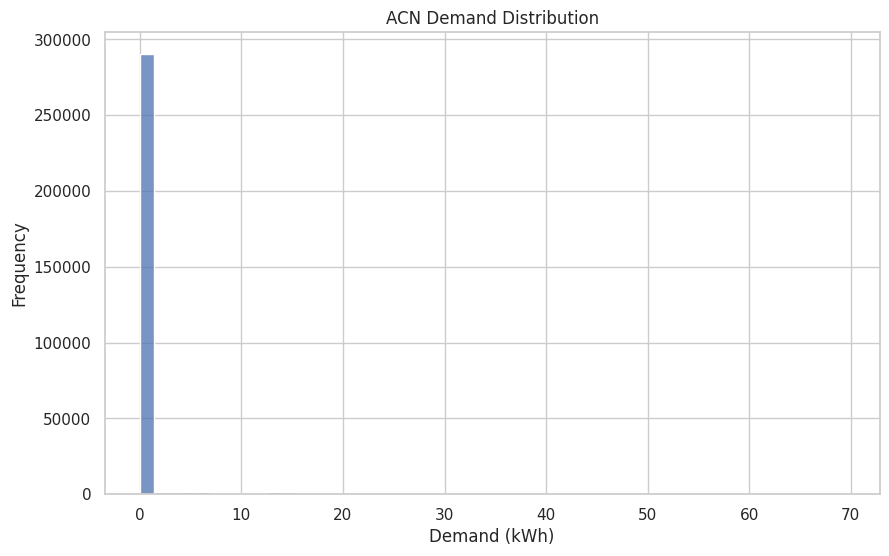

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    acn_final["demand_kwh"],
    bins=50
)

plt.title(
    "ACN Demand Distribution"
)

plt.xlabel(
    "Demand (kWh)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

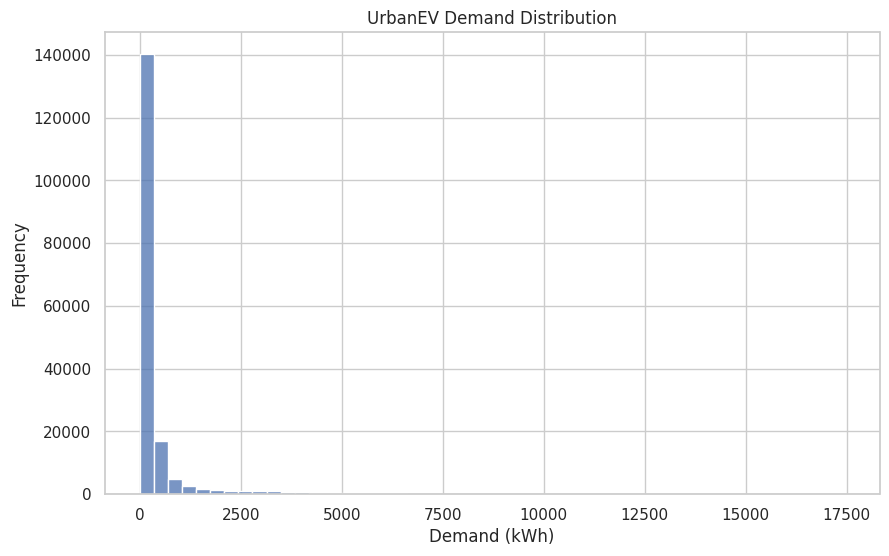

In [9]:
plt.figure(figsize=(10,6))

sns.histplot(
    urban_hourly["demand_kwh"],
    bins=50
)

plt.title(
    "UrbanEV Demand Distribution"
)

plt.xlabel(
    "Demand (kWh)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

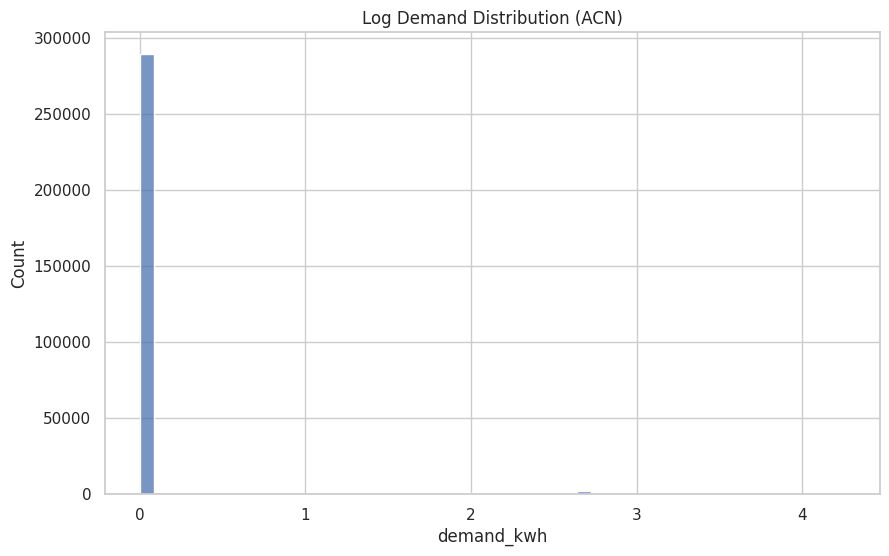

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(
        acn_final["demand_kwh"]
    ),
    bins=50
)

plt.title(
    "Log Demand Distribution (ACN)"
)

plt.show()

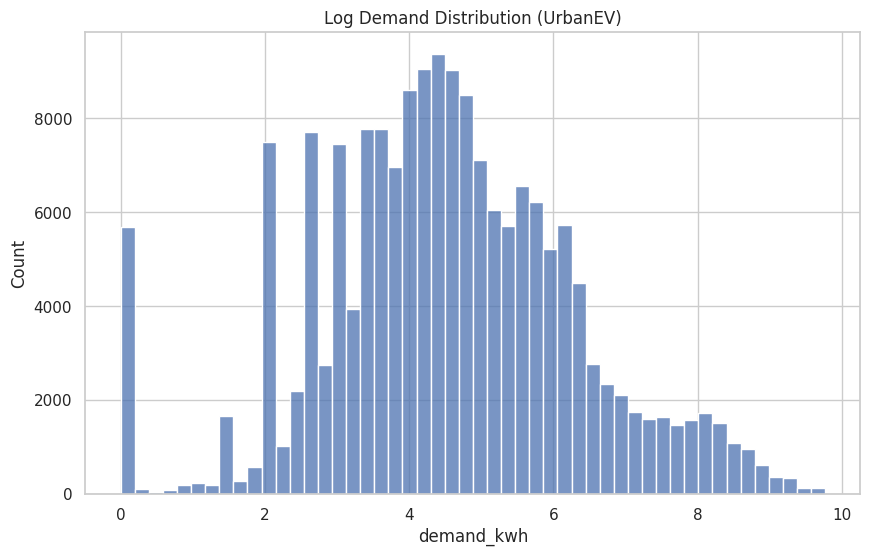

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(
        urban_hourly["demand_kwh"]
    ),
    bins=50
)

plt.title(
    "Log Demand Distribution (UrbanEV)"
)

plt.show()

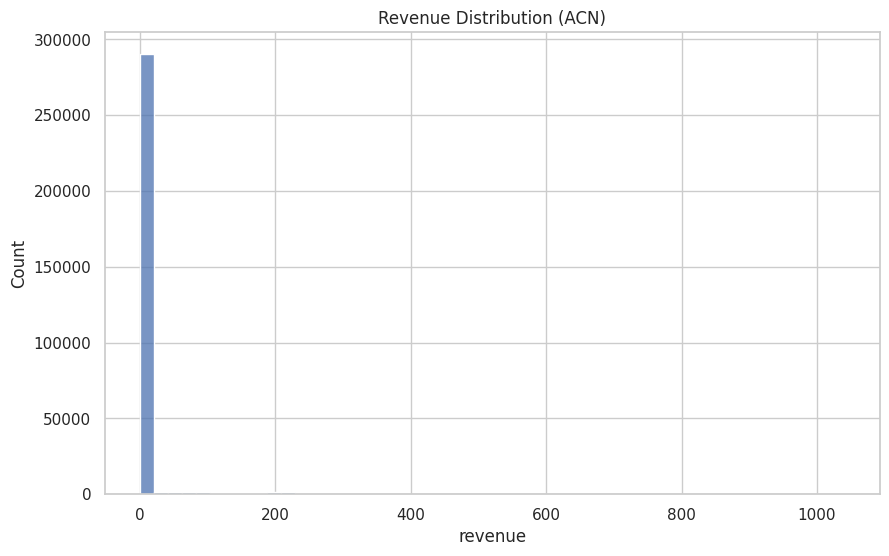

In [12]:
# revenue distribution
plt.figure(figsize=(10,6))

sns.histplot(
    acn_final["revenue"],
    bins=50
)

plt.title(
    "Revenue Distribution (ACN)"
)

plt.show()

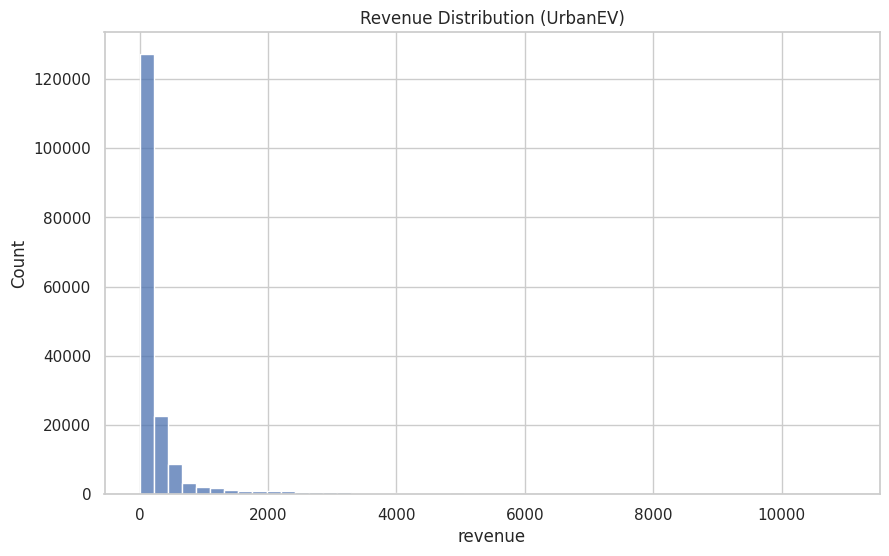

In [13]:
plt.figure(figsize=(10,6))

sns.histplot(
    urban_hourly["revenue"],
    bins=50
)

plt.title(
    "Revenue Distribution (UrbanEV)"
)

plt.show()

In [14]:
acn_final[
    [
        "demand_kwh",
        "revenue"
    ]
].describe()

,demand_kwh,revenue
count,304182.000000,304182.000000
mean,0.443725,6.655870
std,2.502581,37.538715
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,69.373000,1040.595000


In [15]:
urban_hourly[
    [
        "demand_kwh",
        "revenue",
        "utilization_rate"
    ]
].describe()

,demand_kwh,revenue,utilization_rate
count,177840.000000,177840.000000,177840.000000
mean,440.141374,359.986468,0.280242
std,1213.589588,871.016981,0.174434
min,0.000000,0.000000,0.000000
25%,28.000000,27.545000,0.151927
50%,84.000000,81.830000,0.250000
75%,282.019062,262.628604,0.376984
max,17439.004167,10976.642462,1.000000


# EDA Phase 2 (Temporal Demand Analysis)

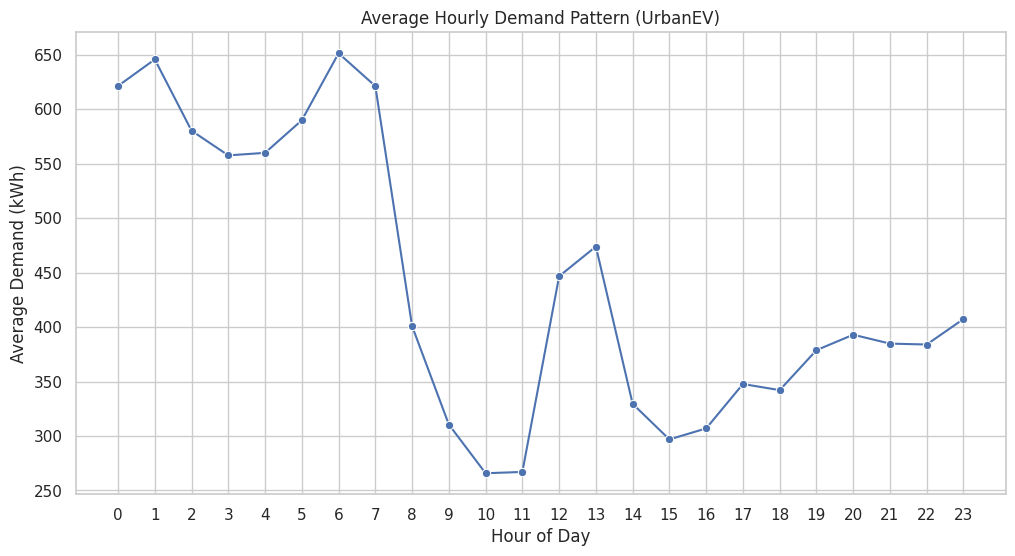

In [16]:
hourly_demand = (
    urban_hourly
    .groupby("hour_of_day")["demand_kwh"]
    .mean()
    .reset_index()
)

#hourly_demand
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_demand,
    x="hour_of_day",
    y="demand_kwh",
    marker="o"
)

plt.title(
    "Average Hourly Demand Pattern (UrbanEV)"
)

plt.xlabel("Hour of Day")

plt.ylabel("Average Demand (kWh)")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [17]:
plt.savefig(
    "UrbanEV_hourly_demand_pattern.png",
    bbox_inches="tight"
)

<Figure size 1000x600 with 0 Axes>

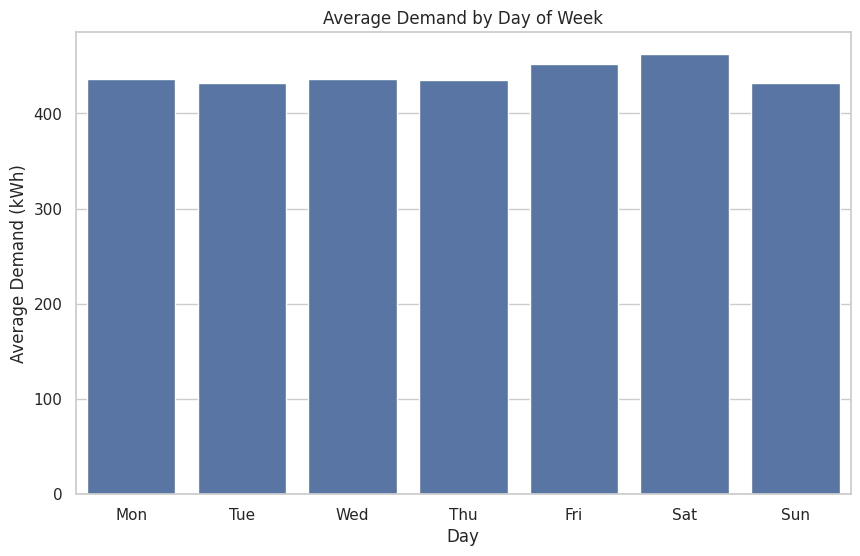

In [18]:
# demand by day of week
dow_demand = (
    urban_hourly
    .groupby("day_of_week")["demand_kwh"]
    .mean()
    .reset_index()
)
day_map = {
    0:"Mon",
    1:"Tue",
    2:"Wed",
    3:"Thu",
    4:"Fri",
    5:"Sat",
    6:"Sun"
}

dow_demand["day_name"] = (
    dow_demand["day_of_week"]
    .map(day_map)
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=dow_demand,
    x="day_name",
    y="demand_kwh"
)

plt.title(
    "Average Demand by Day of Week"
)

plt.xlabel("Day")

plt.ylabel("Average Demand (kWh)")

plt.show()

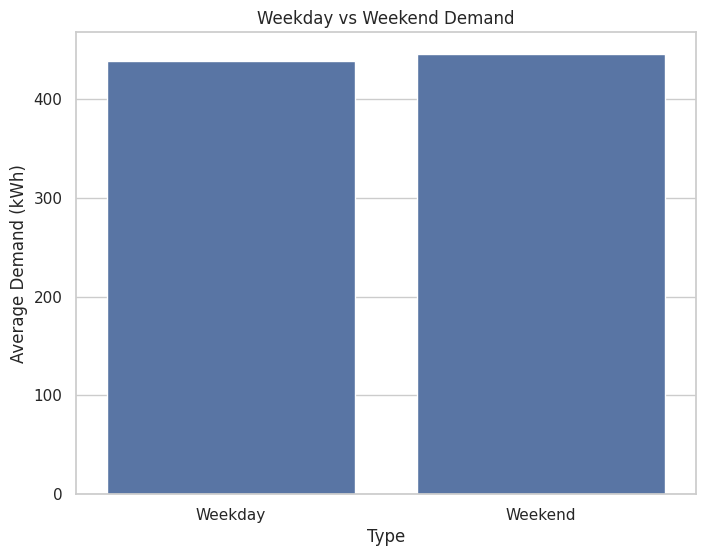

In [19]:
weekend_demand = (
    urban_hourly
    .groupby("is_weekend")["demand_kwh"]
    .mean()
    .reset_index()
)

weekend_demand["label"] = (
    weekend_demand["is_weekend"]
    .map({
        0:"Weekday",
        1:"Weekend"
    })
)
plt.figure(figsize=(8,6))

sns.barplot(
    data=weekend_demand,
    x="label",
    y="demand_kwh"
)

plt.title(
    "Weekday vs Weekend Demand"
)

plt.xlabel("Type")

plt.ylabel("Average Demand (kWh)")

plt.show()

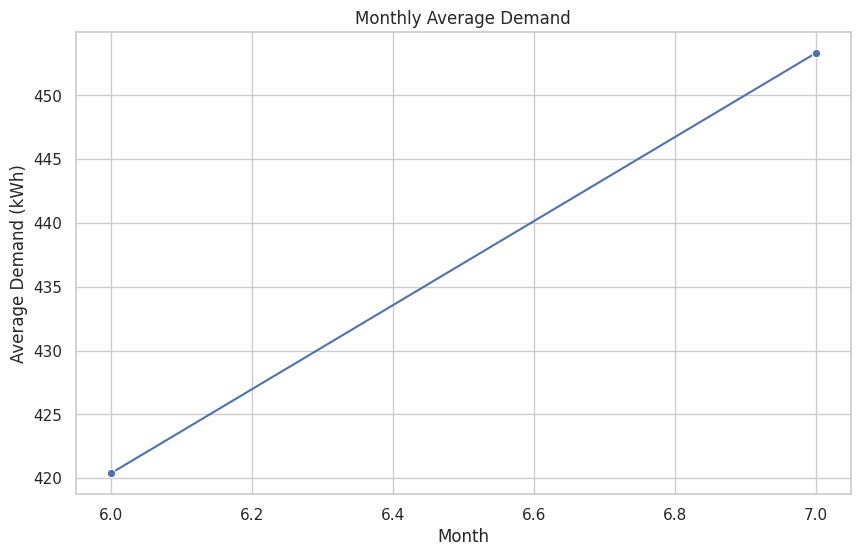

In [20]:
# monthly demand
monthly_demand = (
    urban_hourly
    .groupby("month")["demand_kwh"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_demand,
    x="month",
    y="demand_kwh",
    marker="o"
)

plt.title(
    "Monthly Average Demand"
)

plt.xlabel("Month")

plt.ylabel("Average Demand (kWh)")

plt.show()

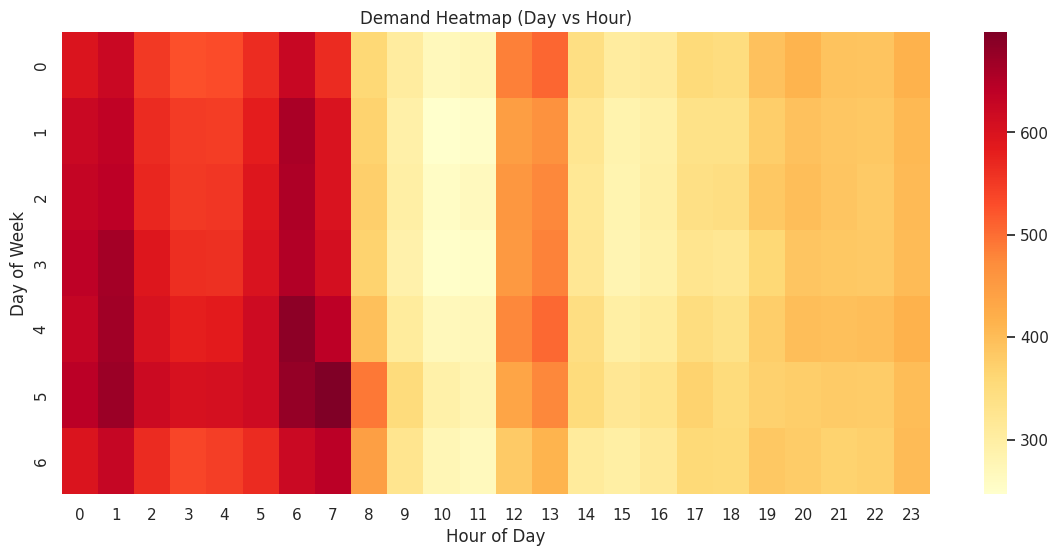

In [21]:
heatmap_data = (
    urban_hourly
    .groupby(
        [
            "day_of_week",
            "hour_of_day"
        ]
    )["demand_kwh"]
    .mean()
    .reset_index()
)
heatmap_pivot = (
    heatmap_data
    .pivot(
        index="day_of_week",
        columns="hour_of_day",
        values="demand_kwh"
    )
)
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_pivot,
    cmap="YlOrRd"
)

plt.title(
    "Demand Heatmap (Day vs Hour)"
)

plt.xlabel("Hour of Day")

plt.ylabel("Day of Week")

plt.show()

In [22]:
plt.savefig(
    "UrbanEVdemand_heatmap.png",
    bbox_inches="tight"
)

<Figure size 1000x600 with 0 Axes>

In [23]:
hourly_demand = (
    urban_hourly
    .groupby("hour_of_day")
    ["demand_kwh"]
    .mean()
)
peak_hours = (
    hourly_demand
    .sort_values(
        ascending=False
    )
    .head(5)
)

peak_hours

hour_of_day
6    651.361389
1    645.719515
0    621.323219
7    621.204020
5    589.845673
Name: demand_kwh, dtype: float64

In [24]:
peak_hours.to_csv(
    "peak_hours.csv"
)

# EDA Phase 3: Utilization & Congestion Analysis

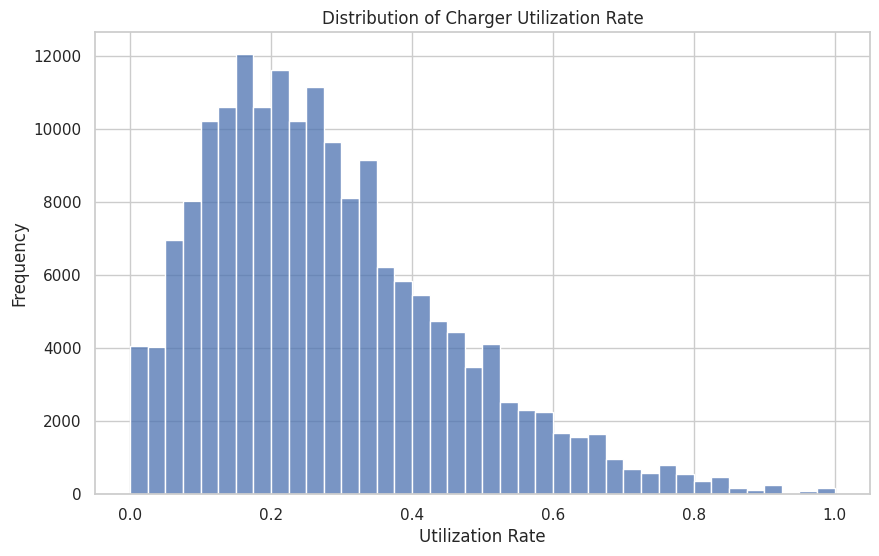

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(
    urban_hourly["utilization_rate"],
    bins=40
)

plt.title(
    "Distribution of Charger Utilization Rate"
)

plt.xlabel(
    "Utilization Rate"
)

plt.ylabel(
    "Frequency"
)

plt.show()

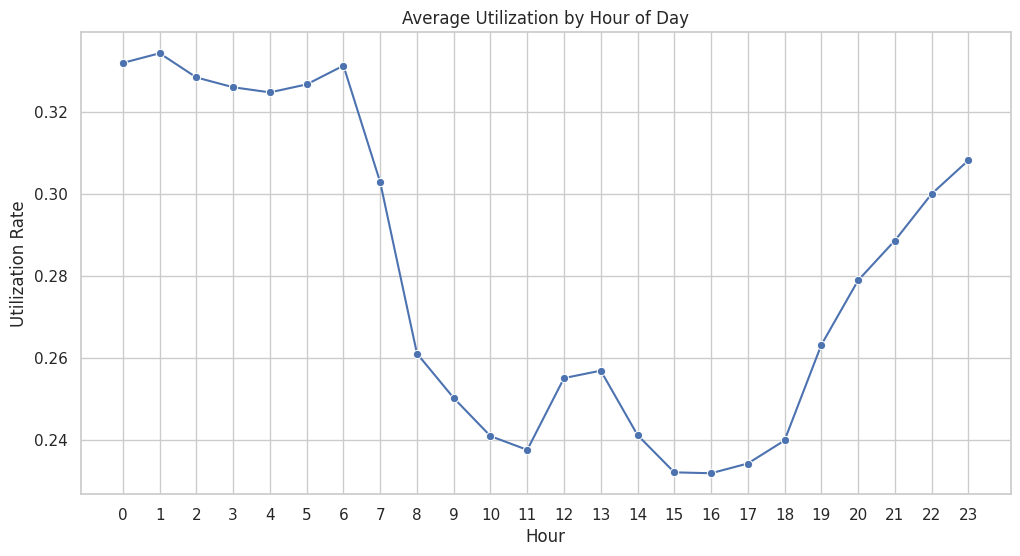

In [26]:
hourly_util = (
    urban_hourly
    .groupby("hour_of_day")
    ["utilization_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_util,
    x="hour_of_day",
    y="utilization_rate",
    marker="o"
)

plt.title(
    "Average Utilization by Hour of Day"
)

plt.xlabel("Hour")

plt.ylabel("Utilization Rate")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [27]:
urban_hourly["congestion_flag"] = (
    urban_hourly["utilization_rate"] > 0.4
).astype(int)
print(urban_hourly["congestion_flag"].value_counts())
urban_hourly["congestion_flag"].mean() * 100

congestion_flag
0    138649
1     39191
Name: count, dtype: int64


np.float64(22.037224471435)

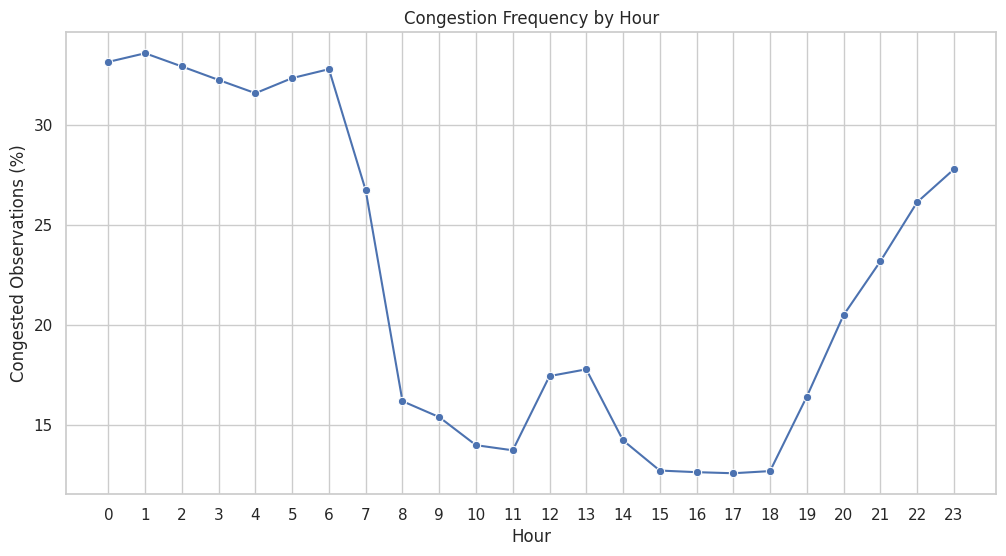

In [28]:
congestion_hour = (
    urban_hourly
    .groupby("hour_of_day")
    ["congestion_flag"]
    .mean()
    .reset_index()
)

congestion_hour["congestion_pct"] = (
    congestion_hour["congestion_flag"] * 100
)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=congestion_hour,
    x="hour_of_day",
    y="congestion_pct",
    marker="o"
)

plt.title(
    "Congestion Frequency by Hour"
)

plt.xlabel("Hour")

plt.ylabel("Congested Observations (%)")

plt.xticks(range(24))

plt.grid(True)

plt.show()

entity_id
1029    0.760269
715     0.733164
570     0.639760
732     0.614578
982     0.589400
1131    0.582488
719     0.579707
835     0.576659
712     0.575697
991     0.561282
102     0.552897
522     0.541629
633     0.541361
691     0.511892
745     0.499694
Name: utilization_rate, dtype: float64

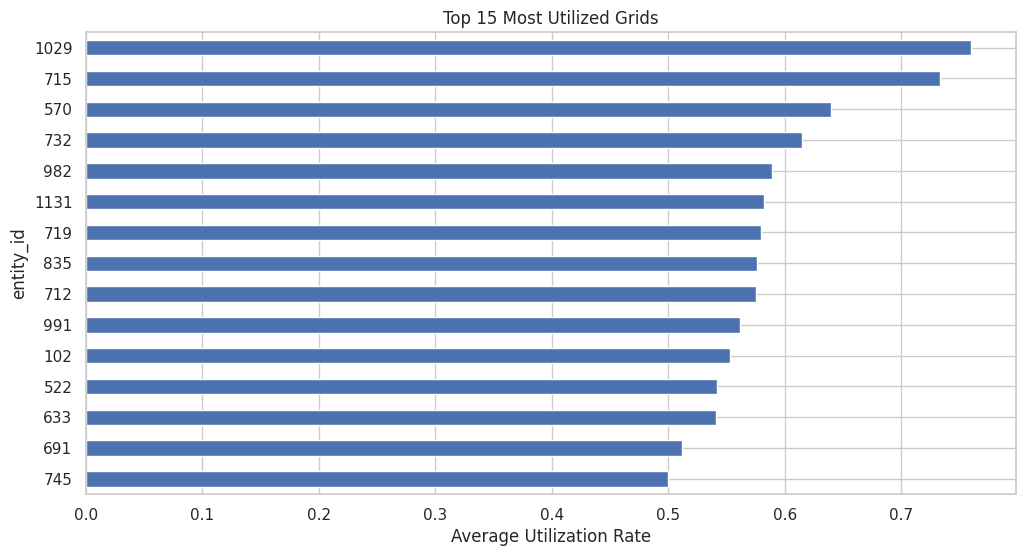

In [29]:
top_congested = (
    urban_hourly
    .groupby("entity_id")
    ["utilization_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

display(top_congested)
plt.figure(figsize=(12,6))

top_congested.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Most Utilized Grids"
)

plt.xlabel(
    "Average Utilization Rate"
)

plt.show()

# EDA Phase 4: Spatial & Capacity Analysis

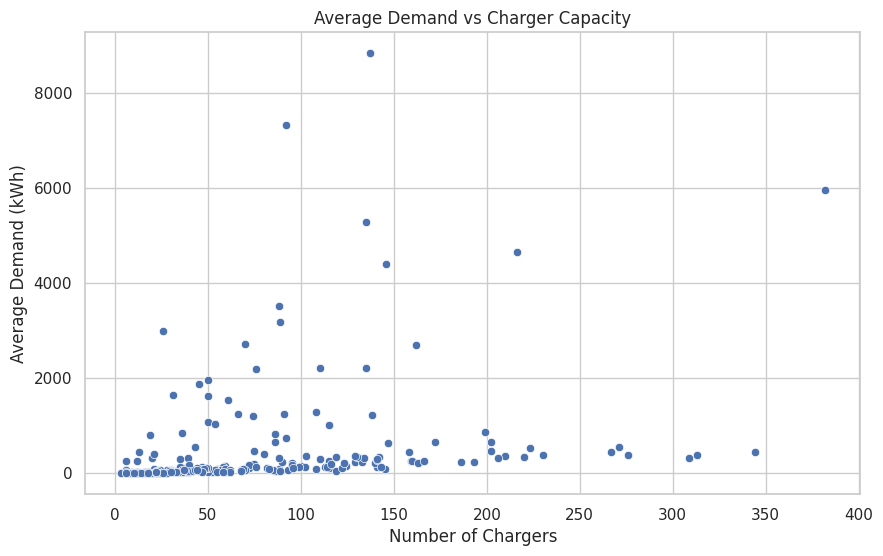

In [30]:
# demand vs charger capacity

capacity_demand = (
    urban_hourly
    .groupby("entity_id")
    .agg(
        avg_demand=("demand_kwh", "mean"),
        charger_count=("charger_count", "first")
    )
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=capacity_demand,
    x="charger_count",
    y="avg_demand"
)

plt.title(
    "Average Demand vs Charger Capacity"
)

plt.xlabel("Number of Chargers")

plt.ylabel("Average Demand (kWh)")

plt.show()

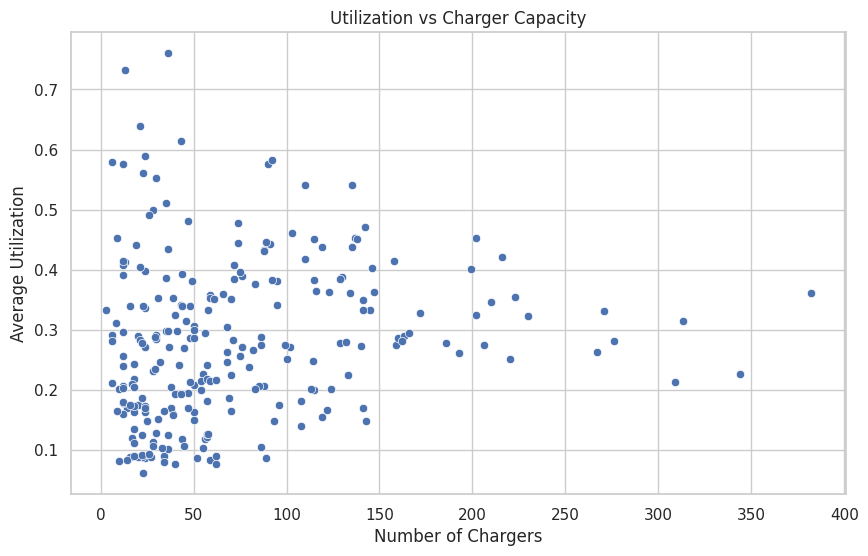

In [31]:
capacity_util = (
    urban_hourly
    .groupby("entity_id")
    .agg(
        avg_utilization=(
            "utilization_rate",
            "mean"
        ),
        charger_count=(
            "charger_count",
            "first"
        )
    )
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=capacity_util,
    x="charger_count",
    y="avg_utilization"
)

plt.title(
    "Utilization vs Charger Capacity"
)

plt.xlabel("Number of Chargers")

plt.ylabel("Average Utilization")

plt.show()

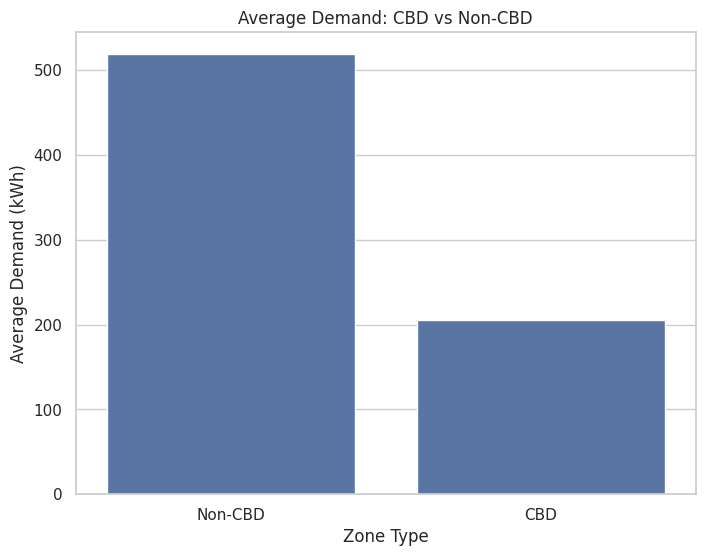

In [32]:
# CBD
cbd_demand = (
    urban_hourly
    .groupby("CBD")
    ["demand_kwh"]
    .mean()
    .reset_index()
)

cbd_demand["zone"] = (
    cbd_demand["CBD"]
    .map({
        0:"Non-CBD",
        1:"CBD"
    })
)
plt.figure(figsize=(8,6))

sns.barplot(
    data=cbd_demand,
    x="zone",
    y="demand_kwh"
)

plt.title(
    "Average Demand: CBD vs Non-CBD"
)

plt.xlabel("Zone Type")

plt.ylabel("Average Demand (kWh)")

plt.show()

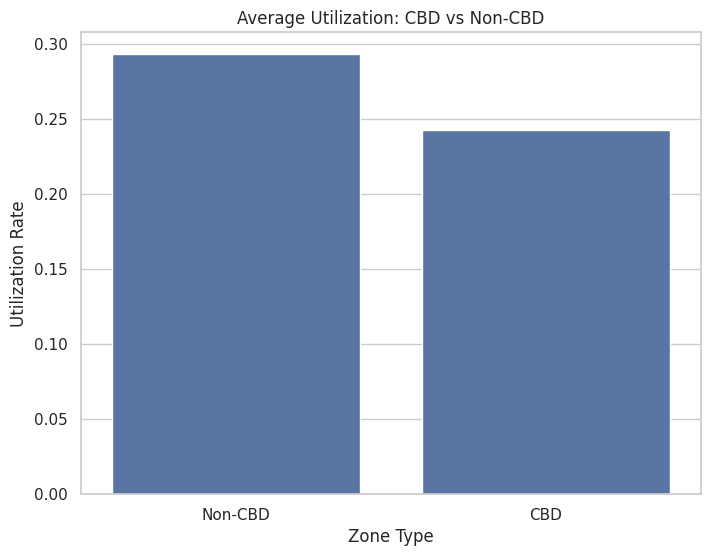

In [33]:
# cbd , non cbd

cbd_util = (
    urban_hourly
    .groupby("CBD")
    ["utilization_rate"]
    .mean()
    .reset_index()
)

cbd_util["zone"] = (
    cbd_util["CBD"]
    .map({
        0:"Non-CBD",
        1:"CBD"
    })
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=cbd_util,
    x="zone",
    y="utilization_rate"
)

plt.title(
    "Average Utilization: CBD vs Non-CBD"
)

plt.xlabel("Zone Type")

plt.ylabel("Utilization Rate")

plt.show()

In [34]:
underutilized = (
    urban_hourly
    .groupby("entity_id")
    ["utilization_rate"]
    .mean()
    .reset_index()
)
underutilized = (
    underutilized[
        underutilized["utilization_rate"] < 0.30
    ]
    .sort_values(
        "utilization_rate"
    )
)
underutilized.head(10)

,entity_id,utilization_rate
7,115,0.061750
224,1122,0.077386
184,1060,0.077538
102,711,0.080406
244,1170,0.082153
12,205,0.083069
237,1160,0.083523
86,686,0.086457
15,215,0.086530
124,783,0.086892


In [35]:
overloaded = (
    urban_hourly
    .groupby("entity_id")
    ["utilization_rate"]
    .mean()
    .reset_index()
)
overloaded = (
    overloaded[
        overloaded["utilization_rate"] > 0.60
    ]
    .sort_values(
        "utilization_rate",
        ascending=False
    )
)
overloaded.head(10)

,entity_id,utilization_rate
178,1029,0.760269
104,715,0.733164
59,570,0.639760
110,732,0.614578


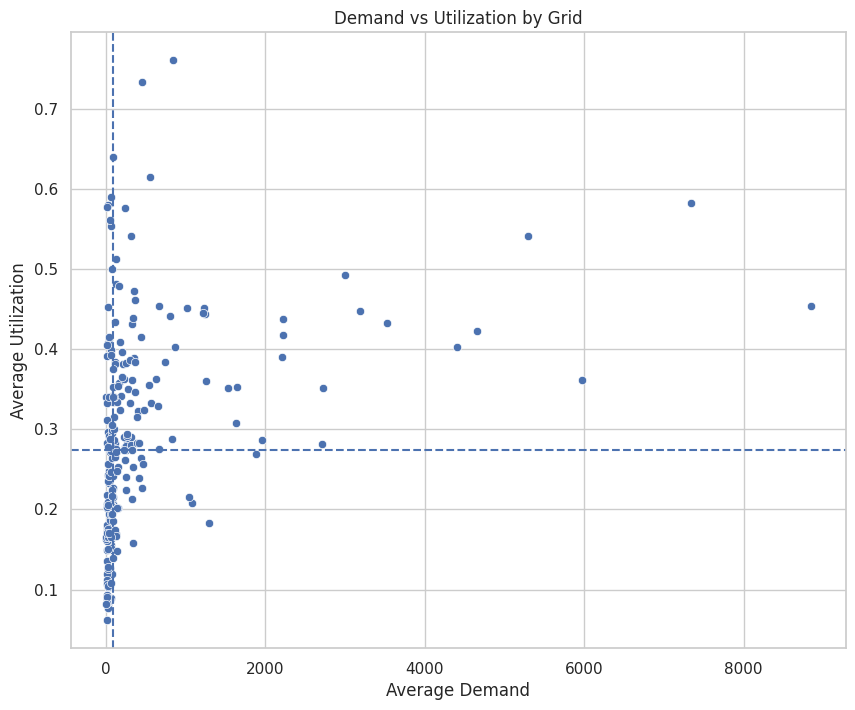

In [36]:
grid_summary = (
    urban_hourly
    .groupby("entity_id")
    .agg(
        avg_demand=(
            "demand_kwh",
            "mean"
        ),
        avg_utilization=(
            "utilization_rate",
            "mean"
        )
    )
    .reset_index()
)

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=grid_summary,
    x="avg_demand",
    y="avg_utilization"
)

plt.axvline(
    grid_summary["avg_demand"].median(),
    linestyle="--"
)

plt.axhline(
    grid_summary["avg_utilization"].median(),
    linestyle="--"
)

plt.title(
    "Demand vs Utilization by Grid"
)

plt.xlabel(
    "Average Demand"
)

plt.ylabel(
    "Average Utilization"
)

plt.show()

# EDA Phase 5 — Pricing & Revenue Analysis

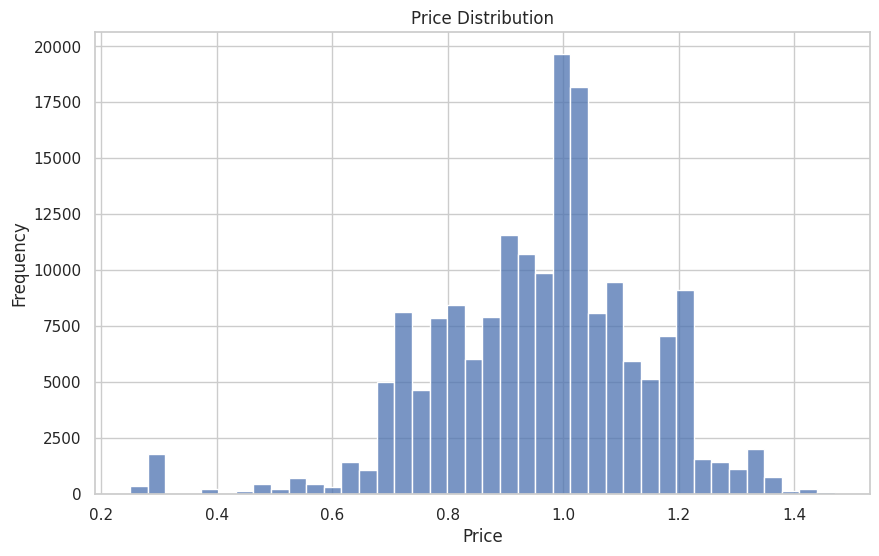

count    177840.000000
mean          0.958571
std           0.181069
min           0.250000
25%           0.849590
50%           0.983750
75%           1.071429
max           1.470000
Name: price, dtype: float64

In [37]:
plt.figure(figsize=(10,6))

sns.histplot(
    urban_hourly["price"],
    bins=40
)

plt.title(
    "Price Distribution"
)

plt.xlabel(
    "Price"
)

plt.ylabel(
    "Frequency"
)

plt.show()
urban_hourly["price"].describe()

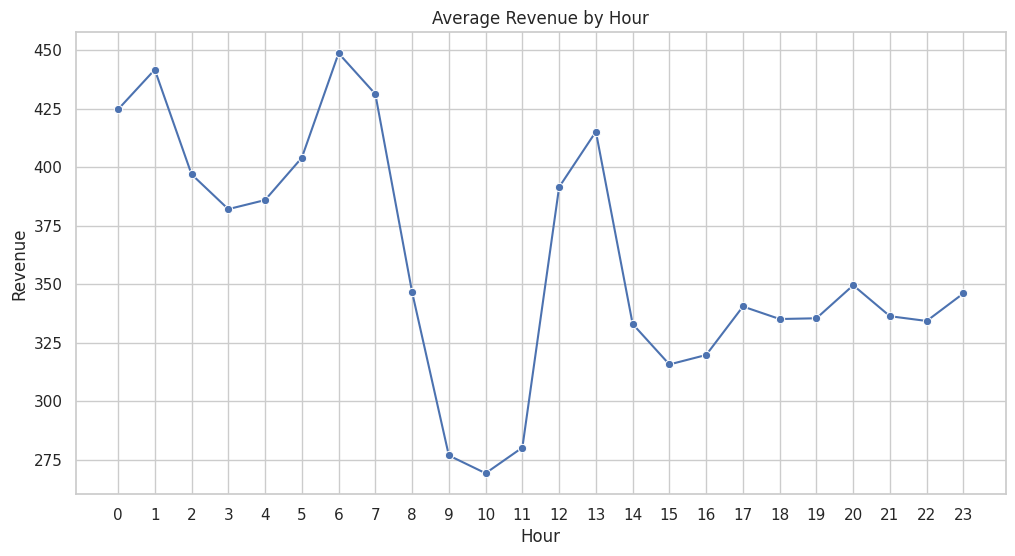

In [38]:
hourly_revenue = (
    urban_hourly
    .groupby("hour_of_day")
    ["revenue"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(12,6))

sns.lineplot(
    data=hourly_revenue,
    x="hour_of_day",
    y="revenue",
    marker="o"
)

plt.title(
    "Average Revenue by Hour"
)

plt.xlabel("Hour")

plt.ylabel("Revenue")

plt.xticks(range(24))

plt.grid(True)

plt.show()

/tmp/ipykernel_16/2511390285.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("util_bin")


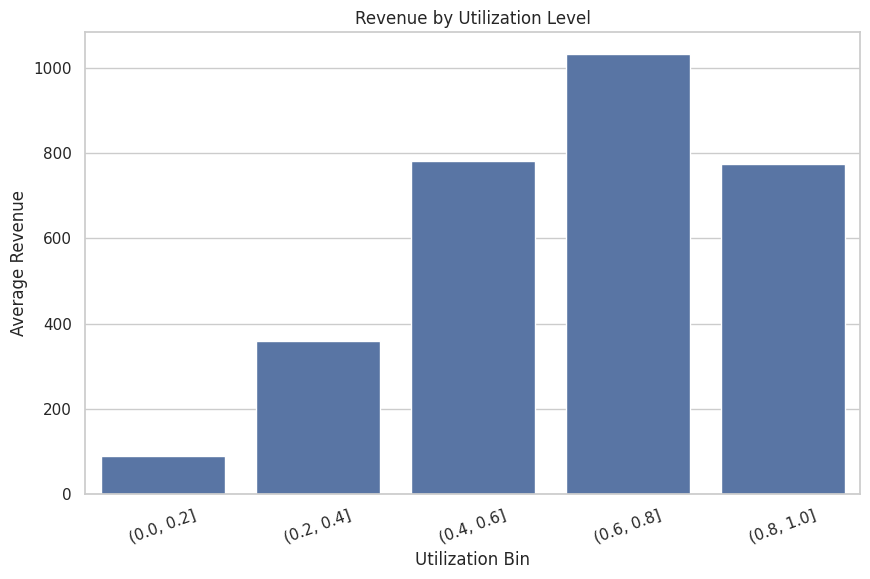

In [39]:
urban_hourly["util_bin"] = pd.cut(
    urban_hourly["utilization_rate"],
    bins=[0,0.2,0.4,0.6,0.8,1.0]
)
util_rev = (
    urban_hourly
    .groupby("util_bin")
    ["revenue"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=util_rev,
    x="util_bin",
    y="revenue"
)

plt.title(
    "Revenue by Utilization Level"
)

plt.xlabel("Utilization Bin")

plt.ylabel("Average Revenue")

plt.xticks(rotation=20)

plt.show()

,price,demand_kwh
price,1.000000,-0.281785
demand_kwh,-0.281785,1.000000


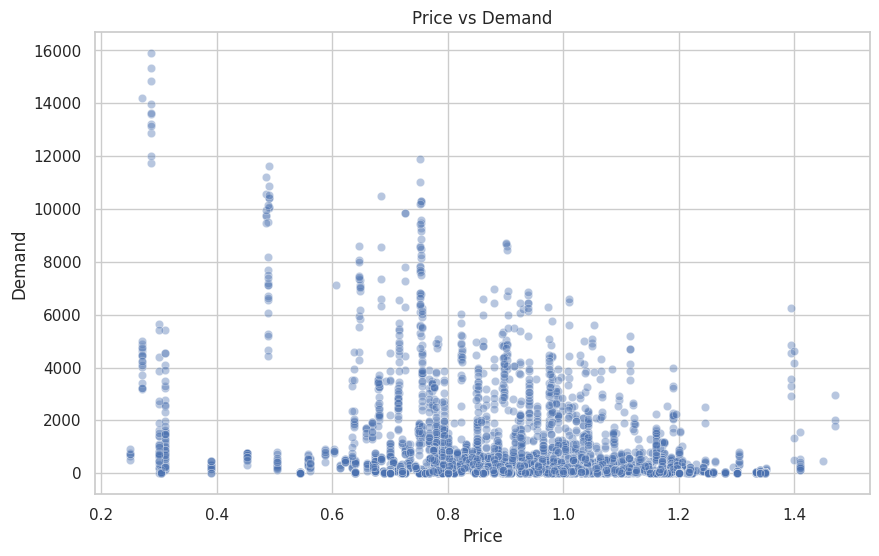

In [40]:
sample_df = urban_hourly.sample(
    10000,
    random_state=42
)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="price",
    y="demand_kwh",
    alpha=0.4
)

plt.title(
    "Price vs Demand"
)

plt.xlabel("Price")

plt.ylabel("Demand")
urban_hourly[
    ["price","demand_kwh"]
].corr()

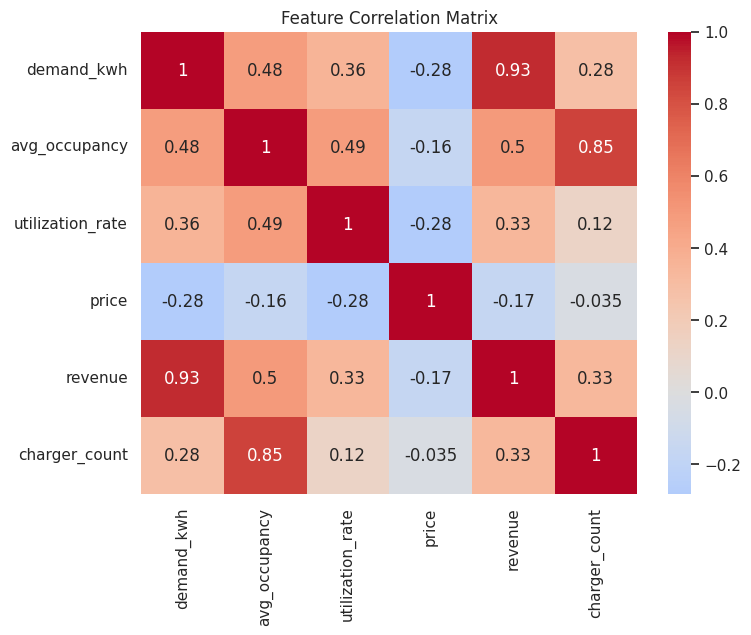

In [41]:
corr_cols = [
    "demand_kwh",
    "avg_occupancy",
    "utilization_rate",
    "price",
    "revenue",
    "charger_count"
]
plt.figure(figsize=(8,6))

sns.heatmap(
    urban_hourly[corr_cols]
    .corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Matrix"
)

plt.show()

/tmp/ipykernel_16/2360279332.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("price_group")


,price_group,demand_kwh
0,Low,873.351525
1,Medium-Low,459.462764
2,Medium-High,248.572888
3,High,177.685428


Text(0, 0.5, 'Average Demand')

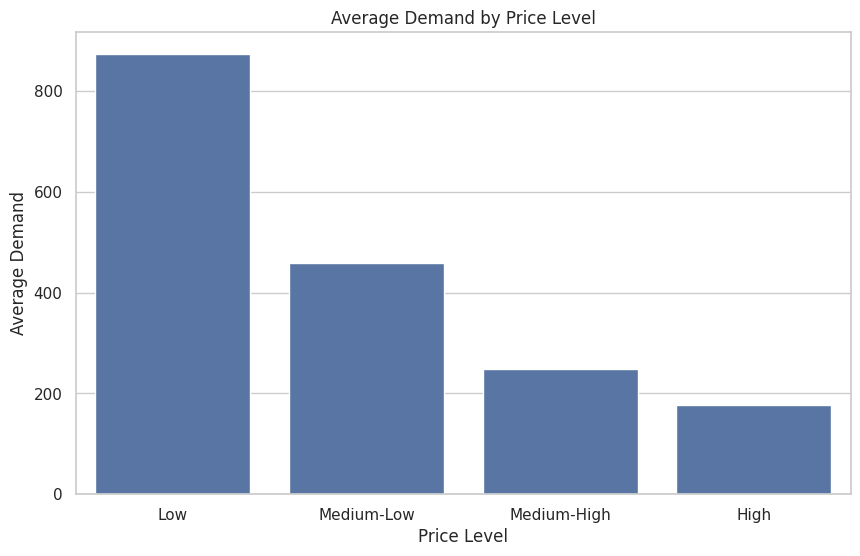

In [42]:
urban_hourly["price_group"] = pd.qcut(
    urban_hourly["price"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ]
)
price_demand = (
    urban_hourly
    .groupby("price_group")
    ["demand_kwh"]
    .mean()
    .reset_index()
)

display(price_demand)
plt.figure(figsize=(10,6))

sns.barplot(
    data=price_demand,
    x="price_group",
    y="demand_kwh"
)

plt.title(
    "Average Demand by Price Level"
)

plt.xlabel("Price Level")

plt.ylabel("Average Demand")

# EDA Phase 6 — Feature Engineering Discovery

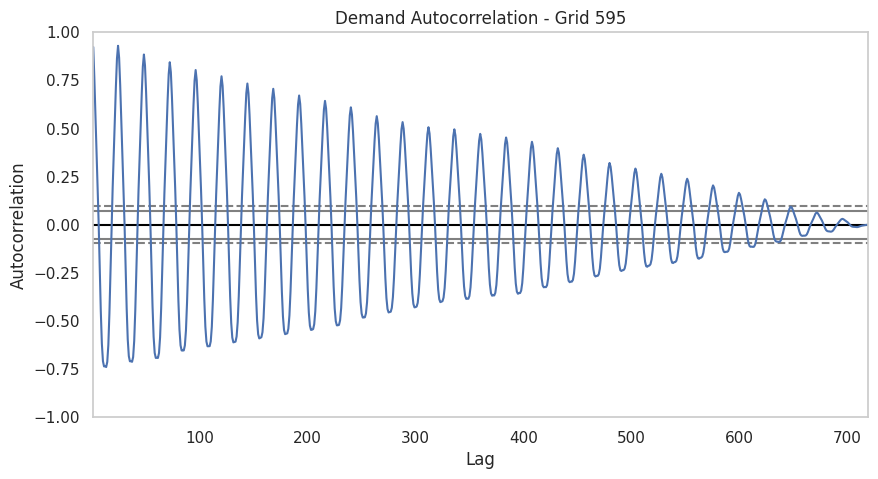

In [43]:
top_grid = (
    urban_hourly.groupby("entity_id")["demand_kwh"]
    .mean()
    .idxmax()
)

grid_ts = (
    urban_hourly[
        urban_hourly["entity_id"] == top_grid
    ]
    .sort_values("hour")
)
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10,5))

autocorrelation_plot(
    grid_ts["demand_kwh"]
)

plt.title(
    f"Demand Autocorrelation - Grid {top_grid}"
)

plt.show()

In [44]:
lags = [1,2,3,6,12,24,48,168]

lag_corr = {}

for lag in lags:

    lag_corr[lag] = (
        grid_ts["demand_kwh"]
        .corr(
            grid_ts["demand_kwh"].shift(lag)
        )
    )

pd.Series(lag_corr)

1      0.923713
2      0.766098
3      0.580896
6      0.011425
12    -0.746871
24     0.959936
48     0.946503
168    0.940162
dtype: float64

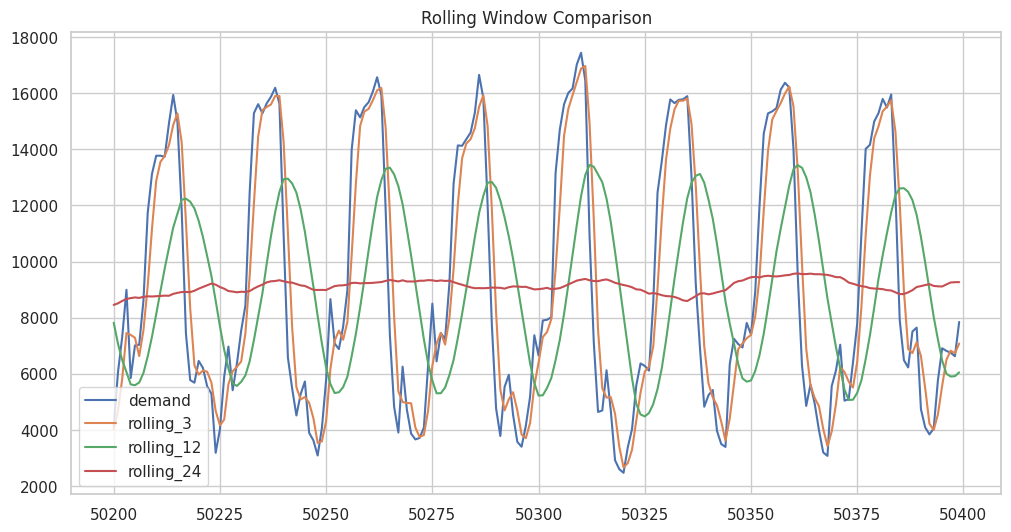

In [45]:
rolling_df = pd.DataFrame({
    "demand": grid_ts["demand_kwh"],
    "rolling_3":
        grid_ts["demand_kwh"]
        .rolling(3)
        .mean(),

    "rolling_12":
        grid_ts["demand_kwh"]
        .rolling(12)
        .mean(),

    "rolling_24":
        grid_ts["demand_kwh"]
        .rolling(24)
        .mean()
})
rolling_df.tail(200).plot(
    figsize=(12,6)
)

plt.title(
    "Rolling Window Comparison"
)

plt.show()

In [46]:
hourly_avg = (
    urban_hourly
    .groupby("hour_of_day")
    ["demand_kwh"]
    .mean()
)
peak_threshold = (
    hourly_avg
    .quantile(0.80)
)
peak_hours = (
    hourly_avg[
        hourly_avg >= peak_threshold
    ]
)

peak_hours

hour_of_day
0    621.323219
1    645.719515
5    589.845673
6    651.361389
7    621.204020
Name: demand_kwh, dtype: float64

In [47]:
urban_hourly[
    "utilization_rate"
].quantile(
    [0.50,0.75,0.90,0.95]
)

0.50    0.250000
0.75    0.376984
0.90    0.520833
0.95    0.617784
Name: utilization_rate, dtype: float64